In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.transforms import blended_transform_factory
from ase import units

from DynamicTopology.io import read_jsonl
from DynamicTopology.forcefield import lj, zbl
from DynamicTopology.forcefield.qforce import QForce

## Morse, and Morse + the Hulburt-Hirschfelder shape term

`QForce.compute_bond` does not write a plain Morse. It writes

$$E(r) \;=\; D\left[\left(1 - e^{-a\,\Delta r}\right)^{2} - 1 + c\,s^{3}e^{-b s}\right],
\qquad a = \sqrt{k/2D}, \quad \Delta r = r - r_0, \quad s = a\,\max(\Delta r,\,0)$$

With $D$ pinned by the atomization energy, $r_0$ by the geometry and $k$ by the vibrational
frequency, two-parameter Morse has no freedom left in between — and what it produces there is
**0.55 to 1.83 eV too deep** at the stretched geometries where reactions happen. A reference
barrier then lands *below* a diabat, and `fit.coupling.fit_amplitude` has a real root only below
both, so eighteen of nineteen HCombustion coupling channels could not be fitted at all.

$c$, with decay $b$, is the freedom that has no other job. Being $O(s^{3})$ it vanishes to second
order at $\Delta r = 0$ and decays back to zero at long range, so it leaves $D$, $r_0$ and the
curvature — and therefore every vibrational frequency — exactly where q-force put them, and lifts
only the branch in between. It is clamped at $\Delta r = 0$ because $s^{3}e^{-bs}$ continued to the
compressed branch grows faster than the Morse wall that has to contain it.

Both curves below are evaluated through `QForce.__call__` itself, on the parameters the shipped
templates actually carry, so nothing here can drift from the force field.

In [12]:
EV = units.kJ / units.mol  # q-force kJ/mol -> ASE eV

# Blue / violet / aqua carry bond identity; orange is reserved throughout for the
# shape-term correction itself, so it never doubles as a series colour.
BLUE, VIOLET, AQUA, ORANGE = "#2a78d6", "#4a3aa7", "#1baf7a", "#eb6834"
INK, MUTED, GRID, BASE = "#0b0b0b", "#52514e", "#dcdbd5", "#5f5e5a"

BOND_FILES = {
    "H-H": ("../datasets/HCombustion/molecules/mol_01.jsonl", BLUE),
    "O=O": ("../datasets/HCombustion/molecules/mol_02.jsonl", VIOLET),
    "O-H": ("../datasets/HCombustion/molecules/mol_04.jsonl", AQUA),
}


def first_bond(path):
    """The `bond` kwargs of a shipped template: `r0` nm, `k` kJ/mol/nm^2, `D` kJ/mol."""
    return next(t["kwargs"] for t in read_jsonl(path) if t["type"] == "bond")


bonds = {name: first_bond(path) for name, (path, _) in BOND_FILES.items()}
colors = {name: color for name, (_, color) in BOND_FILES.items()}

_qforce = QForce(bond_form="morse")


def bond_energy(r, kwargs, c=None):
    """E(r) in eV for one bond, through the public `QForce.__call__`.

    `c=0.0` gives plain Morse; `c=None` keeps the fitted amplitude.  Going
    through the call rather than re-typing the formula means the figure cannot
    drift from `_bond_morse`.
    """
    kw = dict(kwargs)
    if c is not None:
        kw["c"] = c
    term_dict = {
        "bond": {
            "atoms": np.array([[0, 1]]),
            "kwargs": {k: np.array([float(v)]) for k, v in kw.items()},
        }
    }
    pbc, cell = np.zeros(3, dtype=bool), np.eye(3)
    return np.array(
        [
            _qforce(np.array([[0.0, 0.0, 0.0], [x, 0.0, 0.0]]), pbc, cell, term_dict)[0]
            for x in np.atleast_1d(r)
        ]
    )


def shape_geometry(kwargs):
    """`(a [1/A], s_peak, r_peak [A], peak [eV])` of `D c s**3 exp(-b s)`.

    The peak matches `scripts/fit.py:report_force_constants`, which reports
    `(3/b)**3 exp(-3) c D` as the largest correction the term can deliver.
    """
    a = np.sqrt(kwargs["k"] / (2 * kwargs["D"])) / 10.0  # 1/nm -> 1/A
    s_peak = 3.0 / kwargs["b"]
    peak = s_peak**3 * np.exp(-3.0) * kwargs["c"] * kwargs["D"] * EV
    return a, s_peak, kwargs["r0"] * 10.0 + s_peak / a, peak


def r_of_s(s, kwargs):
    """Bond length in Angstrom at reduced stretch `s = a (r - r0)`."""
    a = shape_geometry(kwargs)[0]
    return kwargs["r0"] * 10.0 + np.asarray(s, dtype=float) / a


for name, kw in bonds.items():
    a, s_peak, r_peak, peak = shape_geometry(kw)
    print(
        f"{name}  D={kw['D'] * EV:6.2f} eV  r0={kw['r0'] * 10:.3f} A  "
        f"a={a:.3f} 1/A  c={kw['c']:6.2f}  b={kw['b']:.2f}  "
        f"peak {peak:5.2f} eV at r={r_peak:.2f} A"
    )

H-H  D=  7.70 eV  r0=0.592 A  a=1.620 1/A  c= 16.12  b=6.54  peak  0.60 eV at r=0.87 A
O=O  D= 19.15 eV  r0=1.103 A  a=3.205 1/A  c=  3.24  b=2.41  peak  5.94 eV at r=1.49 A
O-H  D= 10.81 eV  r0=0.790 A  a=1.425 1/A  c= 30.78  b=5.78  peak  2.31 eV at r=1.15 A


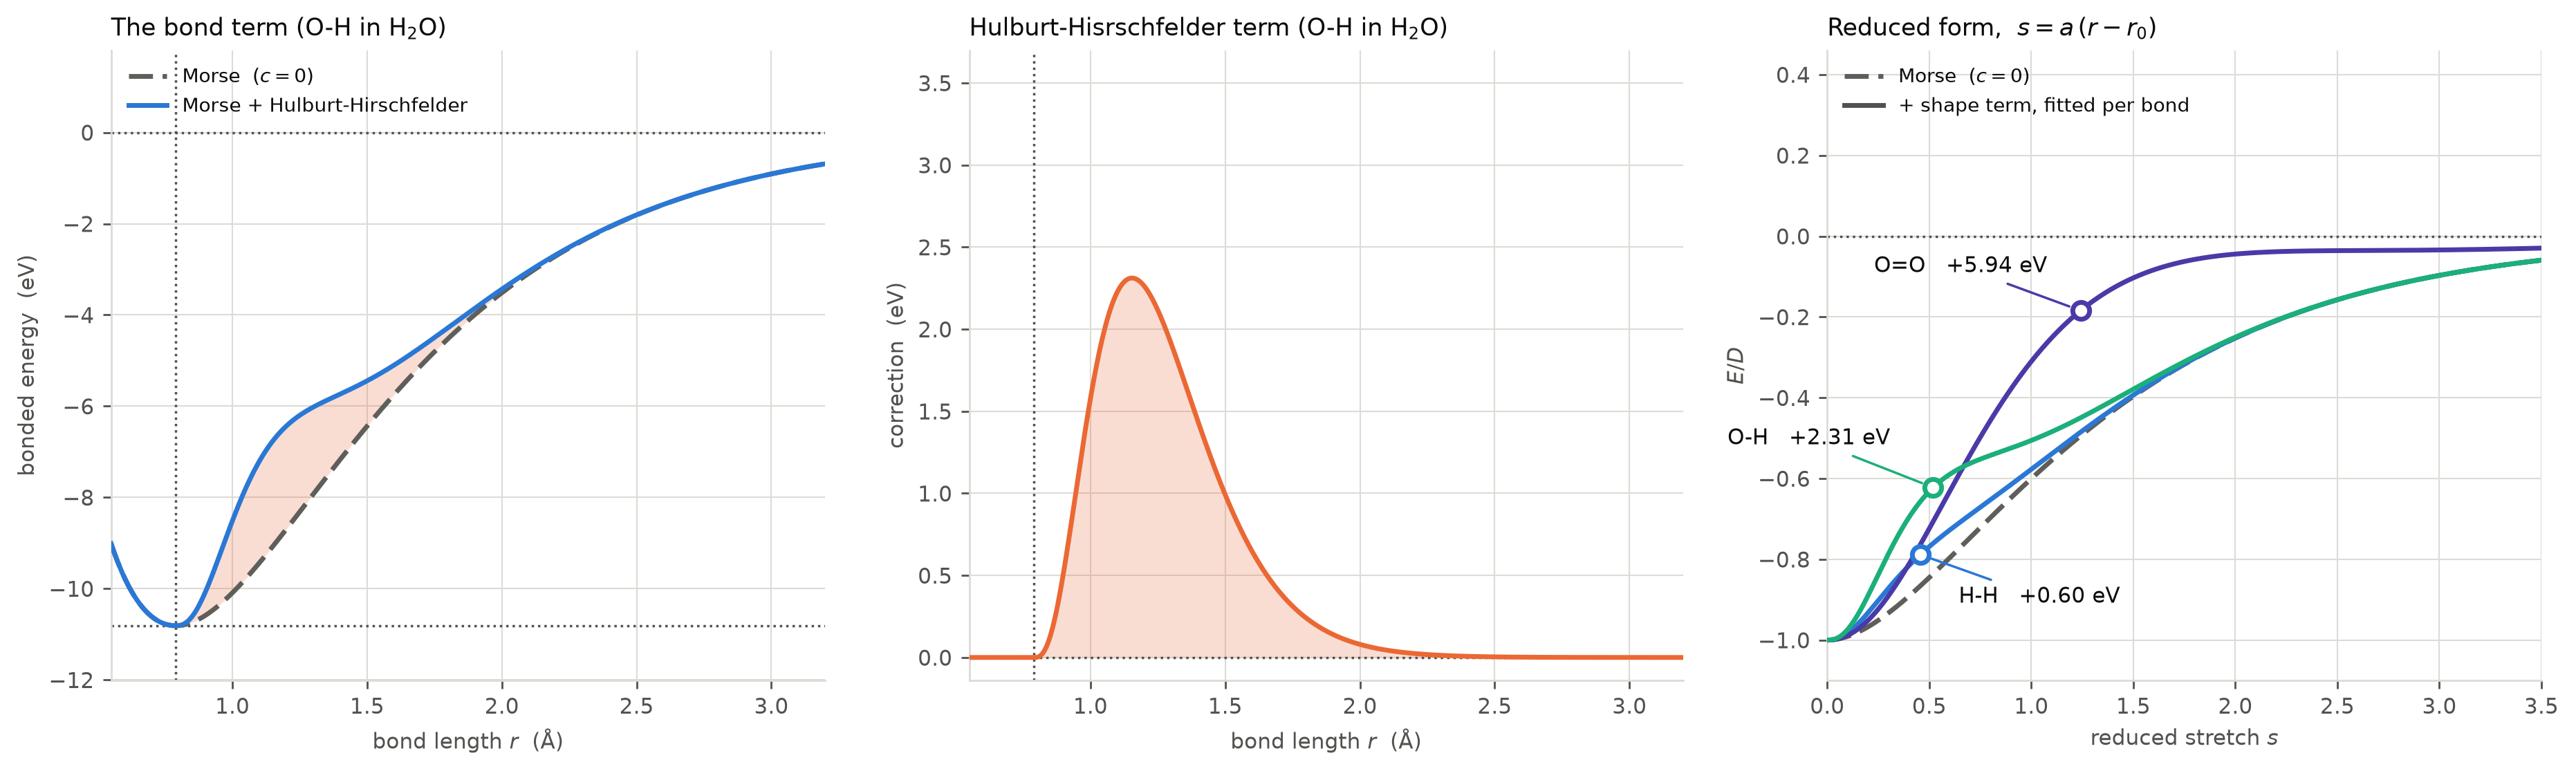

In [13]:
# The three populations the shape term has to serve, in reduced stretch `s`.
# Measured over HCombustion; see the `SHAPE_DECAY` comment in forcefield/qforce.py.
BANDS = [
    ("equilibrium bonds", 0.180, 0.382),
    ("metathesis transition states", 0.352, 1.049),
    ("homolysis, mid-dissociation", 1.081, 1.525),
]

kw = bonds["O-H"]
D_eV = kw["D"] * EV
r0_A = kw["r0"] * 10.0
r = np.linspace(0.55, 3.2, 500)
e_plain = bond_energy(r, kw, c=0.0)
e_shape = bond_energy(r, kw)
a, s_peak, r_peak, peak = shape_geometry(kw)

fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.8), dpi=250)
fig.patch.set_facecolor("white")

# --- A. the bond term, with and without the shape correction -----------------
ax = axes[0]
ax.fill_between(r, e_plain, e_shape, color=ORANGE, alpha=0.22, lw=0, zorder=1)
ax.axhline(0.0, lw=1, ls=":", color=MUTED, zorder=2)
ax.axhline(-D_eV, lw=1, ls=":", color=MUTED, zorder=2)
ax.axvline(r0_A, lw=1, ls=":", color=MUTED, zorder=2)
ax.plot(
    r, e_plain, ls=(0, (5, 2)), lw=2, color=BASE, zorder=3, label="Morse  ($c = 0$)"
)
ax.plot(r, e_shape, lw=2, color=BLUE, zorder=4, label="Morse + Hulburt-Hirschfelder")

j = int(np.argmin(np.abs(r - r_peak)))
# ax.annotate(
#     f"overbinding removed:\n{peak:.2f} eV at {r_peak:.2f} " + "Å",
#     xy=(r_peak, 0.5 * (e_plain[j] + e_shape[j])),
#     xytext=(1.60, -9.7),
#     fontsize=9,
#     color=INK,
#     arrowprops=dict(arrowstyle="-", lw=1, color=ORANGE, shrinkB=2),
# )
ax.set_xlim(0.55, 3.2)
ax.set_ylim(-D_eV - 1.2, 1.8)
ax.set_title("The bond term (O-H in H$_2$O)", fontsize=10, color=INK, loc="left")
ax.set_xlabel("bond length $r$  (Å)", fontsize=9, color=MUTED)
ax.set_ylabel("bonded energy  (eV)", fontsize=9, color=MUTED)
ax.legend(loc="upper left", fontsize=8, frameon=False, labelcolor=INK)

# --- B. the shape term on its own --------------------------------------------
ax = axes[1]
dE = e_shape - e_plain
ax.fill_between(r, 0.0, dE, color=ORANGE, alpha=0.22, lw=0, zorder=1)
ax.axhline(0.0, lw=1, ls=":", color=MUTED, zorder=2)
ax.axvline(r0_A, lw=1, ls=":", color=MUTED, zorder=2)
ax.plot(r, dE, lw=2, color=ORANGE, zorder=4)
# ax.plot([r_peak], [peak], "o", ms=8, mfc="white", mec=ORANGE, mew=2, zorder=5)
# ax.annotate(
#     f"{peak:.2f} eV  at $s = 3/b = {s_peak:.2f}$",
#     xy=(r_peak, peak),
#     xytext=(11, 1),
#     textcoords="offset points",
#     fontsize=9,
#     color=INK,
# )

# span = blended_transform_factory(ax.transData, ax.transAxes)
# for i, (label, s0, s1) in enumerate(BANDS):
#     y = 0.96 - 0.072 * i
#     ax.plot(
#         [r_of_s(s0, kw), r_of_s(s1, kw)],
#         [y, y],
#         transform=span,
#         lw=5,
#         solid_capstyle="butt",
#         color=MUTED,
#         alpha=0.30,
#         zorder=3,
#     )
#     ax.text(
#         r_of_s(s1, kw) + 0.05,
#         y,
#         label,
#         transform=span,
#         va="center",
#         fontsize=8,
#         color=MUTED,
#     )
ax.set_xlim(0.55, 3.2)
ax.set_ylim(-0.14, peak * 1.60)
ax.set_title(
    "Hulburt-Hisrschfelder term (O-H in H$_2$O)",
    fontsize=10,
    color=INK,
    loc="left",
)
ax.set_xlabel("bond length $r$  (Å)", fontsize=9, color=MUTED)
ax.set_ylabel("correction  (eV)", fontsize=9, color=MUTED)

# --- C. reduced form, across bond types --------------------------------------
ax = axes[2]
s = np.linspace(0.0, 3.5, 500)
ax.axhline(0.0, lw=1, ls=":", color=MUTED, zorder=2)
ax.plot(s, (1 - np.exp(-s)) ** 2 - 1.0, ls=(0, (5, 2)), lw=2, color=BASE, zorder=3)
LABEL_POS = {
    "H-H": ((16, -20), "left"),
    "O=O": ((-14, 16), "right"),
    "O-H": ((-18, 18), "right"),
}
for name, kwb in bonds.items():
    reduced = bond_energy(r_of_s(s, kwb), kwb) / (kwb["D"] * EV)
    ax.plot(s, reduced, lw=2, color=colors[name], zorder=4)
    _, s_pk, _, pk = shape_geometry(kwb)
    j = int(np.argmin(np.abs(s - s_pk)))
    ax.plot(
        [s[j]], [reduced[j]], "o", ms=7, mfc="white", mec=colors[name], mew=2, zorder=5
    )
    offset, ha = LABEL_POS[name]
    ax.annotate(
        f"{name}   +{pk:.2f} eV",
        xy=(s[j], reduced[j]),
        xytext=offset,
        textcoords="offset points",
        ha=ha,
        fontsize=9,
        color=INK,
        arrowprops=dict(arrowstyle="-", lw=1, color=colors[name], shrinkB=5),
    )

ax.set_xlim(0.0, 3.5)
ax.set_ylim(-1.10, 0.46)
ax.set_title("Reduced form,  $s = a\\,(r - r_0)$", fontsize=10, color=INK, loc="left")
ax.set_xlabel("reduced stretch $s$", fontsize=9, color=MUTED)
ax.set_ylabel("$E / D$", fontsize=9, color=MUTED)
ax.legend(
    handles=[
        Line2D([], [], ls=(0, (5, 2)), lw=2, color=BASE, label="Morse  ($c = 0$)"),
        Line2D([], [], lw=2, color=MUTED, label="+ shape term, fitted per bond"),
    ],
    loc="upper left",
    fontsize=8,
    frameon=False,
    labelcolor=INK,
)

for ax in axes:
    ax.grid(True, color=GRID, lw=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRID)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=9)

fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

**Left** — the fitted O-H bond of H₂O, with (blue) and without (grey) the shape term. The shaded
area is the overbinding it removes: 2.31 eV at its widest, at 1.15 Å. Both curves share the same
minimum, the same depth $-D$ and the same dissociation limit.

**Middle** — the correction on its own, against the three populations it has to serve (measured
over HCombustion; see the `SHAPE_DECAY` comment in `forcefield/qforce.py`). It peaks at $s = 3/b$,
which is why $b$ is fitted per bond rather than fixed: one decay can be aimed at exactly one of
those bands.

**Right** — in reduced coordinates plain Morse is a *single universal curve*, identical for every
bond, which is the sharpest statement of the problem: the two-parameter form has no per-bond shape
to give. The third parameter is what puts the three bonds on three different curves, worth
+0.60 eV for H-H, +2.31 for O-H and +5.94 for O=O.

Two things this figure is not saying. The correction peaks 0.28-0.39 Å beyond $r_0$ and decays
away after that — it repairs the *stretched-bond* region, and the true asymptote is left exact
by construction. And $D$ and $r_0$ here are the *fitted* values: `fit.dissociation.fit_bond_lengths`
displaces $r_0$ inside the reference bond length so the Morse can lean against `ZBL`, so this bond
term's minimum is not the molecule's minimum, and none of the nonbonded terms are in these curves.

In [14]:
# What the shape term is *not* allowed to move, checked numerically rather than
# taken on faith.  Same invariants as
# `tests/test_fit.py::TestShapeTerm::test_the_shape_term_moves_neither_the_well_nor_the_limit`.
header = f"{'bond':>5s} {'-D':>8s} {'E(r0)':>9s} {'E(20 A)':>9s} {'r < r0':>10s} {'peak numeric':>13s} {'closed form':>12s}"
print(header)
print("-" * len(header))

for name, kwb in bonds.items():
    r0_b, D_b = kwb["r0"] * 10.0, kwb["D"] * EV
    at_min = bond_energy([r0_b], kwb)[0]
    at_inf = bond_energy([20.0], kwb)[0]

    compressed = np.linspace(0.25, r0_b, 60)
    one_sided = np.allclose(
        bond_energy(compressed, kwb, c=0.0), bond_energy(compressed, kwb)
    )

    grid = np.linspace(r0_b, r0_b + 3.0, 2000)
    numeric = float(np.max(bond_energy(grid, kwb) - bond_energy(grid, kwb, c=0.0)))
    closed = shape_geometry(kwb)[3]

    print(
        f"{name:>5s} {-D_b:8.3f} {at_min:9.3f} {at_inf:9.1e} "
        f"{'identical' if one_sided else 'DIFFERS!':>10s} {numeric:13.3f} {closed:12.3f}"
    )
    assert np.isclose(at_min, -D_b), f"{name}: the shape term moved the well depth"
    assert np.isclose(
        at_inf, 0.0
    ), f"{name}: the shape term moved the dissociation limit"
    assert one_sided, f"{name}: the shape term leaked onto the compressed branch"
    assert (
        abs(numeric - closed) < 1e-2
    ), f"{name}: peak disagrees with (3/b)**3 exp(-3) c D"

print("\nwell depth, dissociation limit and the compressed branch: all untouched")

 bond       -D     E(r0)   E(20 A)     r < r0  peak numeric  closed form
------------------------------------------------------------------------
  H-H   -7.700    -7.700  -3.4e-13  identical         0.596        0.596
  O=O  -19.151   -19.151   4.7e-57  identical         5.941        5.941
  O-H  -10.813   -10.813  -2.8e-11  identical         2.312        2.312

well depth, dissociation limit and the compressed branch: all untouched


## The repulsive wall: ZBL, and the 12-6 it replaces

`ACKS2` has no repulsive branch at all. Its Coulomb kernel is finite at contact rather than
divergent, so nothing runs away in the solve itself — but between two atoms of different
electronegativity it is a smooth, monotone, ~4 eV attractive funnel all the way to zero separation.
At 3000 K, $kT$ is 0.26 eV. A 200-atom H₂/O₂ box run against `ACKS2` alone reached 0.60 Å
intermolecular contacts. Something has to stop it.

The obvious candidate is the Lennard-Jones already in the templates, excluded between bonded atoms
the way any fixed-topology force field excludes it. That was tried four times. It fails because
q-force's 12-6 is *enormous* at the separations reactive chemistry visits — a pair at a bond length
is deep inside the $r^{-12}$ core — so a diabatic state that has **broken** a bond pays hundreds of
eV for two atoms that are merely close. Every attempt to strip that penalty made the repulsion
differ between diabatic states, and each one failed in its own way.

`forcefield/zbl.py` takes the screened-nuclear ZBL form instead, and takes **no topology at all**:
its only parameter is the atomic number. A term identical across every diabatic state adds the same
constant to every EVB diagonal, and a common shift moves `np.linalg.eigh`'s eigenvalue by exactly
that constant while leaving the eigenvectors untouched — so it *cannot* produce a plateau or a
spurious coupling amplitude. That is structural, not a tuning.

What it does need is a taper. ZBL's screening function was fitted in the keV nuclear-stopping
regime and carries no information about the range where chemistry happens; evaluated out to
infinity it reaches straight into the hydrogen bond. Both switches below are read from the modules
themselves, so nothing here can drift from the force field.

In [15]:
Z = {"H": 1.0, "O": 8.0}
# q-force's own 12-6 parameters, as any HCombustion template states them.
LJ_SIGMA = {"H": 0.196, "O": 0.296}  # nm
LJ_EPS = {"H": 0.184, "O": 0.71128}  # kJ/mol

R_OH = 0.958  # the O-H bond length
BOND_SPAN = (0.741, 1.208)  # H2's bond to O2's: every bond length in this dataset
HBOND_R, HBOND_E = 1.94, 0.218  # the water dimer's O...H contact, and what it is worth


def zbl_pair(r, e1, e2, bare=False):
    """Tapered ZBL for one pair, in eV; `bare=True` divides the taper back out."""
    r = np.atleast_1d(np.asarray(r, dtype=float))
    u = zbl.pair_potential(r, np.full_like(r, Z[e1]), np.full_like(r, Z[e2]))[0]
    return u / zbl.taper(r)[0] if bare else u


def lj_pair(r, e1, e2, bare=False):
    """Switched 12-6 for one pair, in eV; `bare=True` is the textbook form.

    Geometric combining in both parameters, matching `lj.exclusion_terms`.
    """
    r = np.atleast_1d(np.asarray(r, dtype=float)) / 10.0  # A -> nm
    sigma = np.sqrt(LJ_SIGMA[e1] * LJ_SIGMA[e2])
    eps = np.sqrt(LJ_EPS[e1] * LJ_EPS[e2])
    if bare:
        sr6 = (sigma / r) ** 6
        return 4.0 * eps * (sr6 * sr6 - sr6) * EV
    return lj.pair_potential(r, np.full_like(r, sigma), np.full_like(r, eps))[0] * EV


def repulsive(u):
    """`u` masked to its repulsive branch, so a log axis can carry it.

    12-6 crosses zero at sigma (2.41 A for an O-H pair) and its well is
    -0.0035 eV deep -- three orders under anything else on this panel.
    """
    return np.where(u > 0.0, u, np.nan)


print(f"ZBL   taper radius {zbl.TAPER_RADIUS} Å, width {zbl.TAPER_WIDTH} Å")
print(f"12-6  switch radius {lj.SWITCH_RADIUS * 10} Å, width {lj.SWITCH_WIDTH * 10} Å")
print(
    f"O-H   sigma {np.sqrt(LJ_SIGMA['O'] * LJ_SIGMA['H']) * 10:.3f} Å, "
    f"eps {np.sqrt(LJ_EPS['O'] * LJ_EPS['H']) * EV:.4f} eV"
)

ZBL   taper radius 1.5 Å, width 0.12 Å
12-6  switch radius 2.2 Å, width 0.12 Å
O-H   sigma 2.409 Å, eps 0.0037 eV


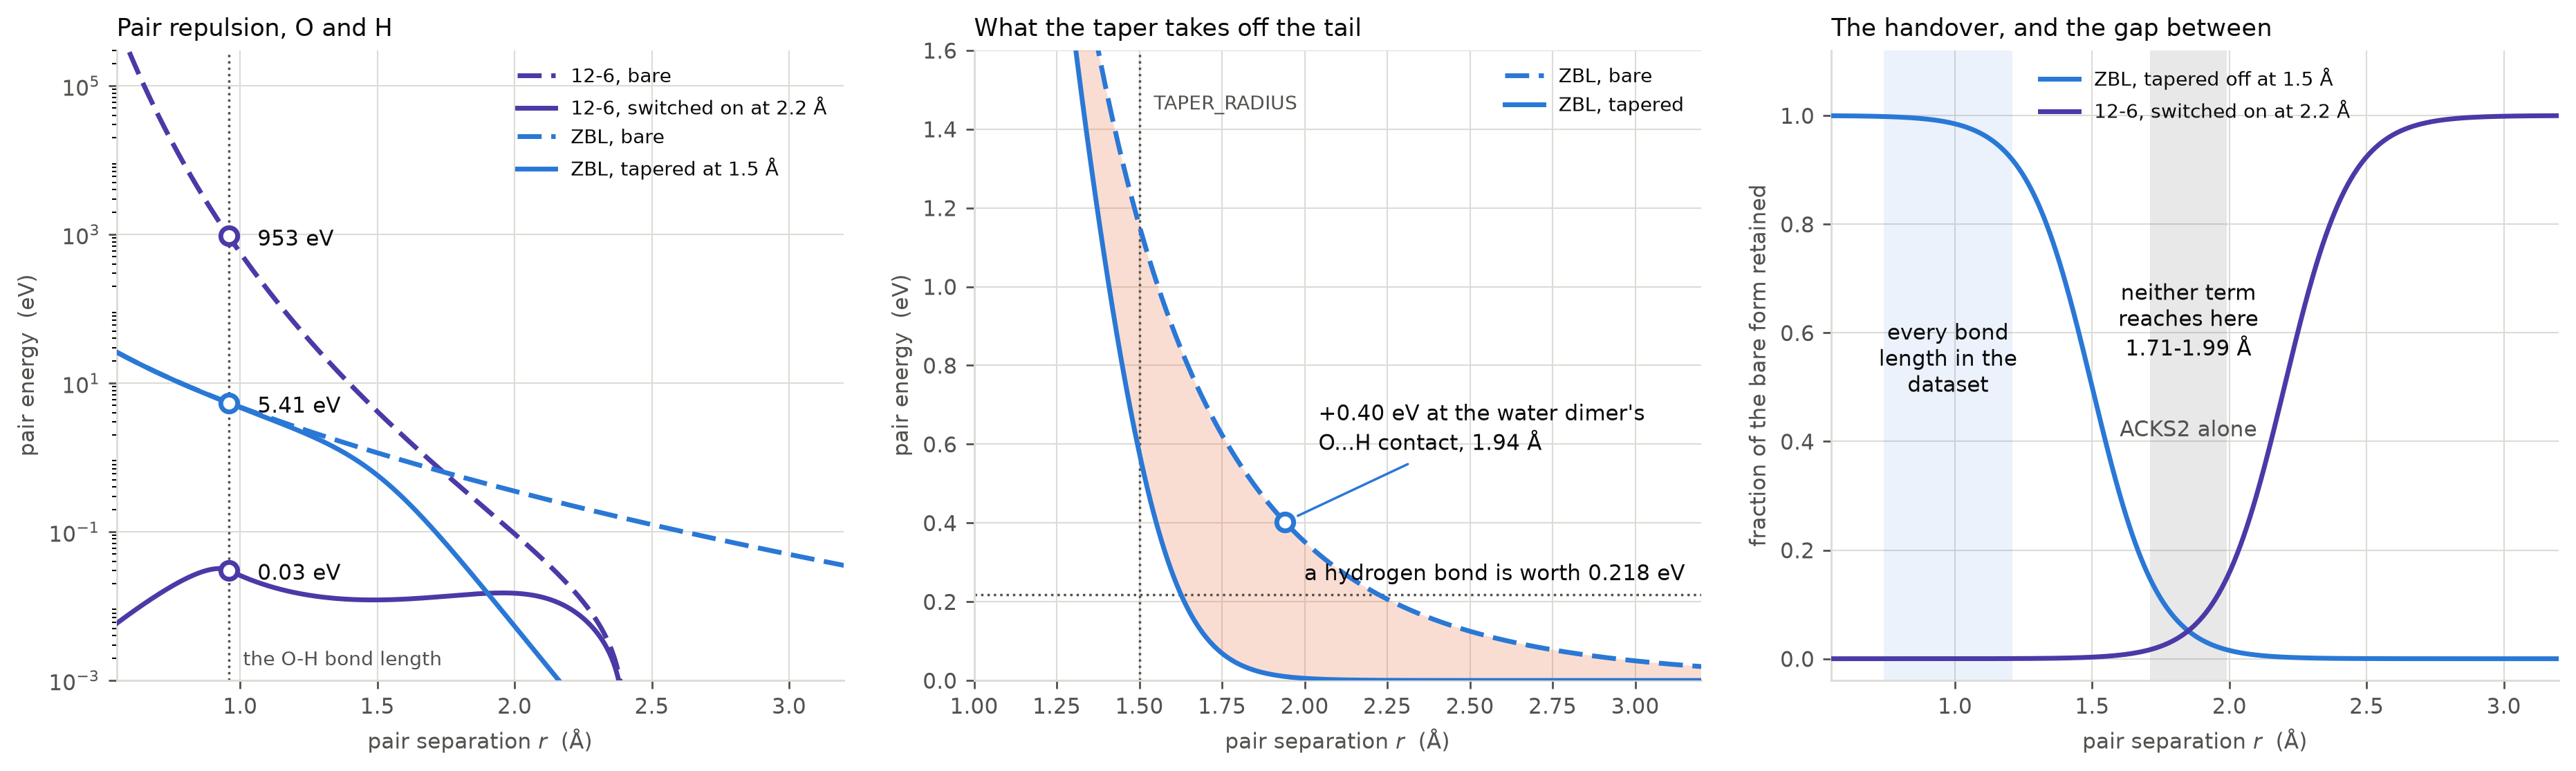

In [16]:
r = np.linspace(0.55, 3.2, 700)

fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.8), dpi=250)
fig.patch.set_facecolor("white")

# --- A. the wall, and the wall it replaces ------------------------------------
ax = axes[0]
ax.axvline(R_OH, lw=1, ls=":", color=MUTED, zorder=2)
ax.plot(
    r,
    repulsive(lj_pair(r, "O", "H", bare=True)),
    ls=(0, (5, 2)),
    lw=2,
    color=VIOLET,
    zorder=3,
    label="12-6, bare",
)
ax.plot(
    r,
    repulsive(lj_pair(r, "O", "H")),
    lw=2,
    color=VIOLET,
    zorder=4,
    label="12-6, switched on at 2.2 Å",
)
ax.plot(
    r,
    zbl_pair(r, "O", "H", bare=True),
    ls=(0, (5, 2)),
    lw=2,
    color=BLUE,
    zorder=5,
    label="ZBL, bare",
)
ax.plot(
    r, zbl_pair(r, "O", "H"), lw=2, color=BLUE, zorder=6, label="ZBL, tapered at 1.5 Å"
)

for value, color, offset in (
    (lj_pair(R_OH, "O", "H", bare=True)[0], VIOLET, (12, -4)),
    (zbl_pair(R_OH, "O", "H")[0], BLUE, (12, -4)),
    (lj_pair(R_OH, "O", "H")[0], VIOLET, (12, -4)),
):
    ax.plot([R_OH], [value], "o", ms=7, mfc="white", mec=color, mew=2, zorder=7)
    ax.annotate(
        f"{value:,.0f} eV" if value > 10 else f"{value:.2f} eV",
        xy=(R_OH, value),
        xytext=offset,
        textcoords="offset points",
        fontsize=9,
        color=INK,
    )
ax.annotate(
    "the O-H bond length",
    xy=(R_OH, 1.6e-3),
    xytext=(6, 0),
    textcoords="offset points",
    fontsize=8,
    color=MUTED,
)

ax.set_yscale("log")
ax.set_xlim(0.55, 3.2)
ax.set_ylim(1e-3, 3e5)

ax.set_yticks([1e-3, 1e-1, 1e1, 1e3, 1e5])
ax.set_title("Pair repulsion, O and H", fontsize=10, color=INK, loc="left")
ax.set_xlabel("pair separation $r$  (Å)", fontsize=9, color=MUTED)
ax.set_ylabel("pair energy  (eV)", fontsize=9, color=MUTED)
ax.legend(loc="upper right", fontsize=8, frameon=False, labelcolor=INK)

# --- B. what the taper takes off the tail -------------------------------------
ax = axes[1]
rb = np.linspace(1.0, 3.2, 500)
bare, tapered = zbl_pair(rb, "O", "H", bare=True), zbl_pair(rb, "O", "H")
ax.fill_between(rb, tapered, bare, color=ORANGE, alpha=0.22, lw=0, zorder=1)
ax.axhline(HBOND_E, lw=1, ls=":", color=MUTED, zorder=2)
ax.axvline(zbl.TAPER_RADIUS, lw=1, ls=":", color=MUTED, zorder=2)
ax.plot(rb, bare, ls=(0, (5, 2)), lw=2, color=BLUE, zorder=3, label="ZBL, bare")
ax.plot(rb, tapered, lw=2, color=BLUE, zorder=4, label="ZBL, tapered")

u_contact = zbl_pair(HBOND_R, "O", "H", bare=True)[0]
ax.plot([HBOND_R], [u_contact], "o", ms=7, mfc="white", mec=BLUE, mew=2, zorder=5)
ax.annotate(
    f"+{u_contact:.2f} eV at the water dimer's\nO...H contact, {HBOND_R} Å",
    xy=(HBOND_R, u_contact),
    xytext=(14, 30),
    textcoords="offset points",
    fontsize=9,
    color=INK,
    arrowprops=dict(arrowstyle="-", lw=1, color=BLUE, shrinkB=6),
)
ax.annotate(
    f"a hydrogen bond is worth {HBOND_E:.3f} eV",
    xy=(3.15, HBOND_E),
    xytext=(0, 6),
    textcoords="offset points",
    ha="right",
    fontsize=9,
    color=INK,
)
ax.annotate(
    "TAPER_RADIUS",
    xy=(zbl.TAPER_RADIUS, 1.45),
    xytext=(6, 0),
    textcoords="offset points",
    fontsize=8,
    color=MUTED,
)

ax.set_xlim(1.0, 3.2)
ax.set_ylim(0.0, 1.6)
ax.set_title("What the taper takes off the tail", fontsize=10, color=INK, loc="left")
ax.set_xlabel("pair separation $r$  (Å)", fontsize=9, color=MUTED)
ax.set_ylabel("pair energy  (eV)", fontsize=9, color=MUTED)
ax.legend(loc="upper right", fontsize=8, frameon=False, labelcolor=INK)

# --- C. the handover, and the gap ---------------------------------------------
ax = axes[2]
f = zbl.taper(r)[0]
g = lj.switch(r / 10.0)[0]
inside = np.maximum(f, g) < 0.15
gap = (r[inside][0], r[inside][-1])

ax.axvspan(*BOND_SPAN, color=BLUE, alpha=0.09, lw=0, zorder=1)
ax.axvspan(*gap, color=MUTED, alpha=0.13, lw=0, zorder=1)
ax.plot(r, f, lw=2, color=BLUE, zorder=4, label="ZBL, tapered off at 1.5 Å")
ax.plot(r, g, lw=2, color=VIOLET, zorder=4, label="12-6, switched on at 2.2 Å")

ax.annotate(
    "every bond\nlength in the\ndataset",
    xy=(np.mean(BOND_SPAN), 0.55),
    ha="center",
    va="center",
    fontsize=9,
    color=INK,
)
ax.annotate(
    f"neither term\nreaches here\n{gap[0]:.2f}-{gap[1]:.2f} Å",
    xy=(np.mean(gap), 0.62),
    ha="center",
    va="center",
    fontsize=9,
    color=INK,
)
ax.annotate(
    "ACKS2 alone",
    xy=(np.mean(gap), 0.42),
    ha="center",
    va="center",
    fontsize=9,
    color=MUTED,
)

ax.set_xlim(0.55, 3.2)
ax.set_ylim(-0.04, 1.12)
ax.set_title("The handover, and the gap between", fontsize=10, color=INK, loc="left")
ax.set_xlabel("pair separation $r$  (Å)", fontsize=9, color=MUTED)
ax.set_ylabel("fraction of the bare form retained", fontsize=9, color=MUTED)
ax.legend(loc="upper center", fontsize=8, frameon=False, labelcolor=INK)

for ax in axes:
    ax.grid(True, color=GRID, lw=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRID)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=9)

fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

**Left** — the same O and H pair, under both forms, on a log axis. At the O-H bond length the bare
12-6 is **953 eV** and ZBL is **5.4 eV**: that factor of ~180 is the whole reason the short range is
carried by a screened-nuclear form. ZBL's few eV are absorbed by the fitted Morse depths —
`fit/dissociation.py` solves against `E_QForce + E_nonbonded` — so a template still reproduces its
own atomization energy. The 12-6 is not gone; `lj.switch` turns it on at 2.2 Å, which is what takes
it to 0.03 eV here and lets it carry no exclusions at all. (Log axis, so only the repulsive branch
is drawn: the 12-6 crosses zero at $\sigma = 2.41$ Å and its well is 0.0035 eV deep.)

**Middle** — the tail the taper removes. Untapered, this pair contributes **+0.40 eV** at the water
dimer's O···H contact, against a hydrogen bond worth −0.218 eV — the repulsion is roughly twice the
bond it is sitting on. Summed over the assembled dimer that came to +0.72 eV, and the dimer was
unbound with no minimum at any separation; a 64-water box read +172 eV and **+251 kbar** of
intermolecular ZBL. Tapered, the same pair contributes +0.01 eV.

**Right** — where each form is switched on, as the retained fraction. Every bond length in the
dataset sits where ZBL is ≳ 92% intact, which is why the taper is a refit rather than a rebuild.
The two radii are deliberately **not** complementary: a Fermi switch decays one $e$-fold per
$w$ while 12-6 grows as $r^{-12}$, and at ZBL's own 1.5 Å the 12-6 is still 953 eV against a switch
of $1.1\times10^{-2}$ — +10.3 eV per O-H bond, +20.6 eV on a single water. So a gap opens where
neither term reaches, and `ACKS2` carries the hydrogen bond through it alone. That is not a
compromise reached by accident: `tests/test_collapse.py` asserts an intermolecular approach is
still uphill through the gap, because "both terms are small here" is exactly the shape of the hole
a box fuses through.

Two things this figure is not. These are **pair** potentials, not the assembled surface — `ACKS2`,
which supplies the attraction and the hydrogen bond, is not drawn, and neither is the bonded term.
And `TAPER_RADIUS` and `SWITCH_RADIUS` are read live from the modules, so the curves track an edit
to either — but the `.jsonl` parameters would not: both constants sit inside `E_nonbonded`, so
changing one invalidates every dataset until `scripts/fit.py --force-constants` is re-run.

In [17]:
# What the two switches are claimed to do, checked against the forms themselves
# rather than against the tables in the module docstrings.
PAIRS = {
    "H-H": (("H", "H"), 0.741),
    "O-H": (("O", "H"), 0.958),
    "O-O": (("O", "O"), 1.208),
}

header = (
    f"{'pair':>5s} {'r (Å)':>7s} {'ZBL bare':>9s} {'tapered':>9s} {'kept':>7s}"
    f" {'12-6 bare':>10s} {'switched':>9s} {'cut by':>9s}"
)
print(header)
print("-" * len(header))

for name, (elements, r_bond) in PAIRS.items():
    kept = float(zbl.taper(np.array([r_bond]))[0][0])
    z_bare = zbl_pair(r_bond, *elements, bare=True)[0]
    z_taper = zbl_pair(r_bond, *elements)[0]
    l_bare = lj_pair(r_bond, *elements, bare=True)[0]
    l_switch = lj_pair(r_bond, *elements)[0]
    print(
        f"{name:>5s} {r_bond:7.3f} {z_bare:9.3f} {z_taper:9.3f} {kept:7.3f}"
        f" {l_bare:10.1f} {l_switch:9.4f} {l_bare / l_switch:8.0f}x"
    )
    # The taper is placed so the wall survives where the Morse depths absorb it.
    assert kept > 0.90, f"{name}: the taper ate the wall at its own bond length"
    # And the switch is what lets the 12-6 carry no exclusions.
    assert l_bare / l_switch > 1e3, f"{name}: the 12-6 is still large at a bond length"

# Neither form is ever amplified, and the gap really is a gap.
r_check = np.linspace(0.3, 8.0, 2000)
assert np.all(
    zbl_pair(r_check, "O", "H") <= zbl_pair(r_check, "O", "H", bare=True) + 1e-12
)
in_gap = (r_check > gap[0]) & (r_check < gap[1])
assert np.all(
    np.maximum(zbl.taper(r_check)[0], lj.switch(r_check / 10.0)[0])[in_gap] < 0.15
)

# The switch travels with its own derivative, or the analytic forces silently
# stop matching the energy -- the property `tests/test_gradients.py` owns.
h = 1e-5
z1 = np.full_like(r_check, Z["O"])
z2 = np.full_like(r_check, Z["H"])
analytic = zbl.pair_potential(r_check, z1, z2)[1]
numeric = (
    zbl.pair_potential(r_check + h, z1, z2)[0]
    - zbl.pair_potential(r_check - h, z1, z2)[0]
) / (2 * h)
worst = float(np.max(np.abs(analytic - numeric)))
assert worst < 1e-4, f"tapered ZBL gradient off by {worst:.2e} eV/Å"

print(
    f"\ntaper > 90% at every bond length; 12-6 cut by >1000x there; "
    f"gap {gap[0]:.2f}-{gap[1]:.2f} Å; worst dZBL/dr error {worst:.1e} eV/Å"
)

 pair   r (Å)  ZBL bare   tapered    kept  12-6 bare  switched    cut by
------------------------------------------------------------------------
  H-H   0.741     2.315     2.311   0.998      892.1    0.0039   226363x
  O-H   0.958     5.465     5.406   0.989      953.2    0.0304    31334x
  O-O   1.208    11.655    10.715   0.919     1375.1    0.3532     3893x

taper > 90% at every bond length; 12-6 cut by >1000x there; gap 1.71-1.99 Å; worst dZBL/dr error 1.2e-06 eV/Å


## The 12-6, and the two things done to it

The Lennard-Jones in the templates is q-force's own, and it is *enormous* where reactive chemistry
happens — **892 eV** at the H₂ bond length, **953** at O-H, **1375** at O-O. A fixed-topology force
field never notices, because those pairs are always excluded. A reactive one does: a diabatic state
that has **broken** a bond calls its two atoms different molecules while they sit at the bond
length, and pays hundreds of eV for it. The term was retired over this, and four attempts to strip
the penalty each failed differently — a box that fused at 0.60 Å, a 19 eV plateau across rxn_16's
reaction path, EVB amplitudes of −72 to −108 eV. All four descend from one root: *a pair at a bond
length being charged hundreds of eV, and the charge depending on the topology.*

`forcefield/lj.py` removes the root rather than the symptoms, with two modifications to the
standard form:

- **`lj.switch` turns the term on at 2.2 Å**, so at a bond length it is three to four orders of
  magnitude smaller. At that size there is no penalty worth stripping, so nothing is stripped and
  the term carries **no exclusions at all** — and a term with no exclusions is the same number on
  every diabatic state, so it adds a common shift to every EVB diagonal and `np.linalg.eigh` moves
  its eigenvalue by exactly that constant with the eigenvectors untouched.
- **Below $0.4\,\sigma$ the potential continues along its own tangent** instead of as $r^{-12}$,
  which bounds what a compressed bond can put into the sum.

Both constants are read from the module below, so nothing here can drift from the force field.

In [18]:
R_OO, R_HH = 1.208, 0.741


def lj_u(r, e1, e2, core=True):
    """The 12-6 itself, in eV, before the switch. `core=False` is textbook r^-12."""
    r = np.atleast_1d(np.asarray(r, dtype=float)) / 10.0
    sigma = np.sqrt(LJ_SIGMA[e1] * LJ_SIGMA[e2])
    eps = np.sqrt(LJ_EPS[e1] * LJ_EPS[e2])
    if not core:
        sr6 = (sigma / r) ** 6
        return 4.0 * eps * (sr6 * sr6 - sr6) * EV
    r_core = lj.CORE_FRACTION * sigma
    r_eval = np.maximum(r, r_core)
    sr6 = (sigma / r_eval) ** 6
    u = 4.0 * eps * (sr6 * sr6 - sr6)
    du = -(24.0 * eps / r_eval) * (2.0 * sr6 * sr6 - sr6)
    return np.where(r < r_core, u + du * (r - r_core), u) * EV


def lj_eval(r, e1, e2, core=True):
    """`g(r) * u(r)` -- what the force field actually adds up, in eV."""
    return (
        lj_u(r, e1, e2, core) * lj.switch(np.atleast_1d(np.asarray(r, float)) / 10.0)[0]
    )


print(
    f"CORE_FRACTION {lj.CORE_FRACTION} -> 0.4 sigma = "
    f"{lj.CORE_FRACTION * LJ_SIGMA['H'] * 10:.3f} Å for H-H, "
    f"{lj.CORE_FRACTION * LJ_SIGMA['O'] * 10:.3f} Å for O-O"
)
print(f"H2's bond sits at {R_HH} Å and O2's at {R_OO} Å, so for H-H the tangent is")
print("already in use at equilibrium -- see the caption for what that costs.")

CORE_FRACTION 0.4 -> 0.4 sigma = 0.784 Å for H-H, 1.184 Å for O-O
H2's bond sits at 0.741 Å and O2's at 1.208 Å, so for H-H the tangent is
already in use at equilibrium -- see the caption for what that costs.


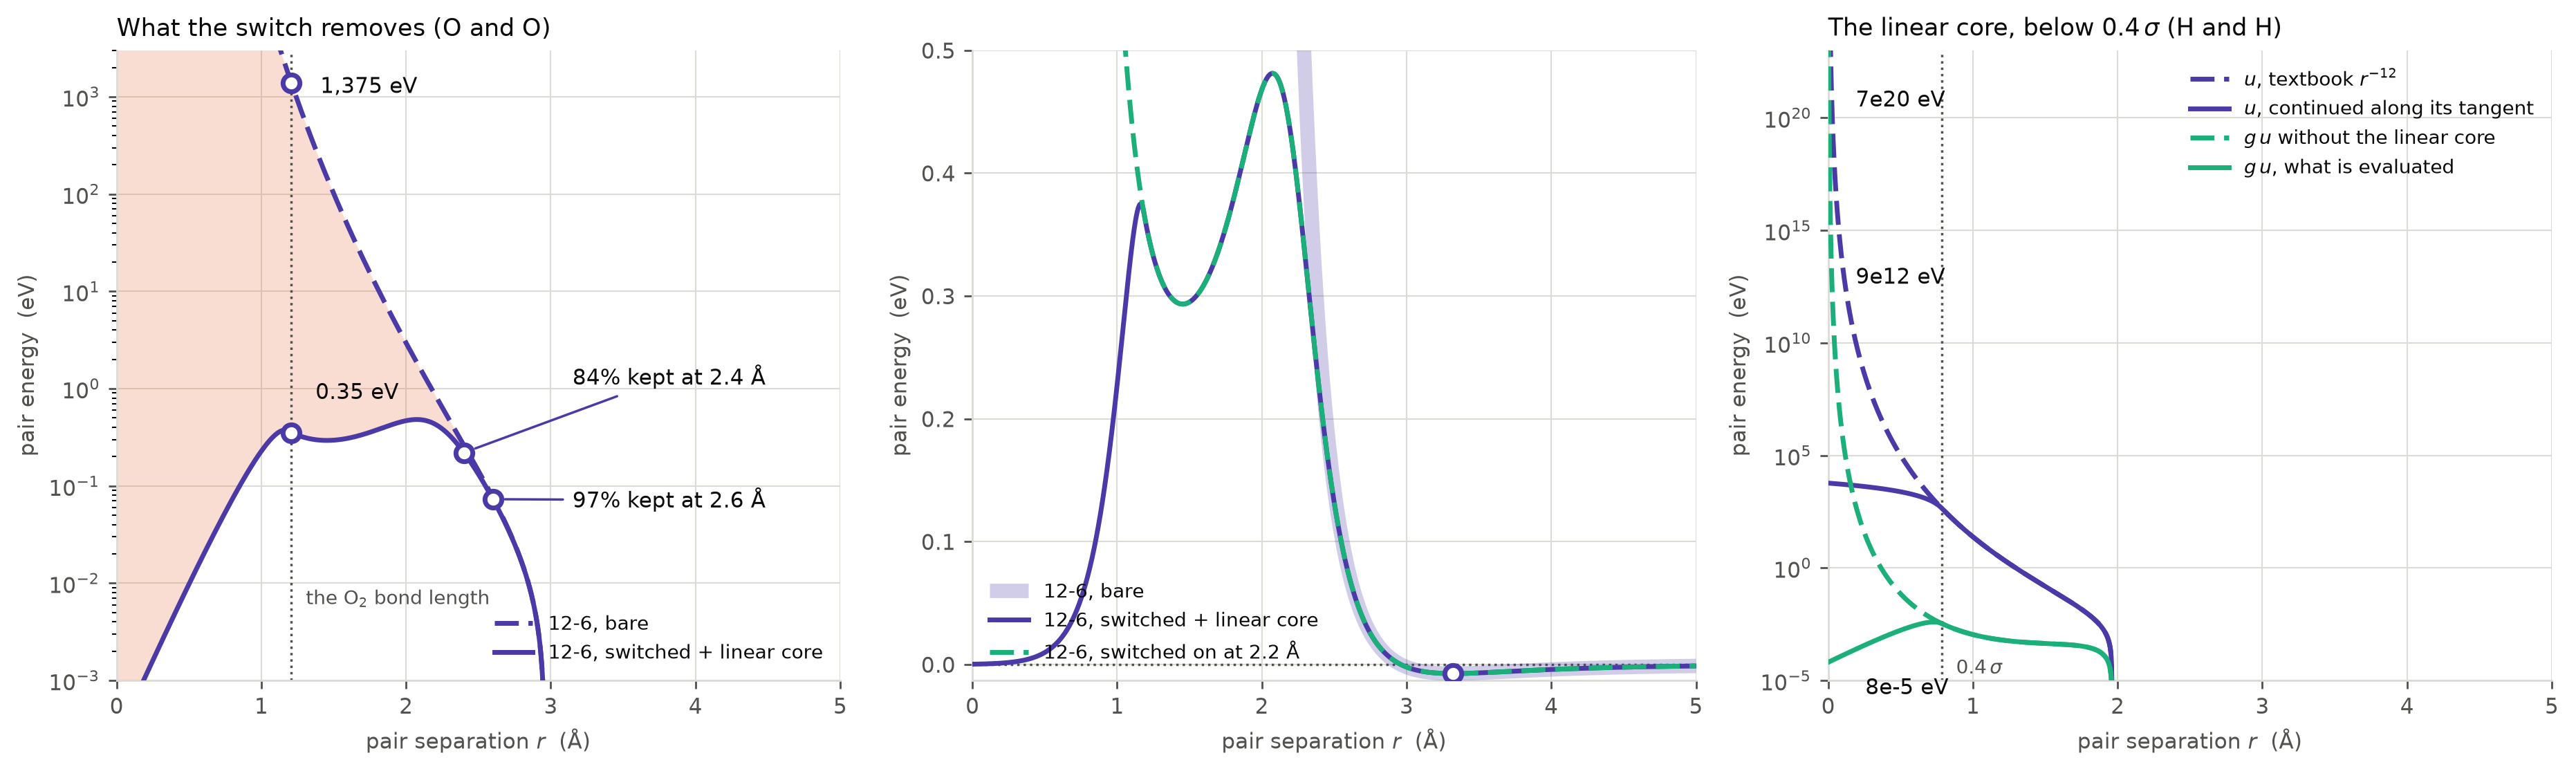

In [25]:
# One x window for all three panels: the core sits at the left, the wall in the
# middle and the well at the right, so the three views read across.
SHARED_X = (0.0, 5.0)
# One grid too, so all three panels are literally the same samples of r.  It
# starts just off zero because the textbook form divides by r.
r = np.linspace(1e-3, SHARED_X[1], 2400)

fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.8), dpi=250)
fig.patch.set_facecolor("white")

# --- A. what the switch removes ------------------------------------------------
ax = axes[0]
bare, switched = lj_u(r, "O", "O", core=False), lj_eval(r, "O", "O")
ax.fill_between(
    r, repulsive(switched), repulsive(bare), color=ORANGE, alpha=0.22, lw=0, zorder=1
)
ax.axvline(R_OO, lw=1, ls=":", color=MUTED, zorder=2)
ax.plot(
    r, repulsive(bare), ls=(0, (5, 2)), lw=2, color=VIOLET, zorder=3, label="12-6, bare"
)
ax.plot(
    r,
    repulsive(switched),
    lw=2,
    color=VIOLET,
    zorder=4,
    label="12-6, switched + linear core",
)

for value, offset in (
    (lj_u(R_OO, "O", "O", core=False)[0], (12, -4)),
    (lj_eval(R_OO, "O", "O")[0], (10, 14)),
):
    ax.plot([R_OO], [value], "o", ms=7, mfc="white", mec=VIOLET, mew=2, zorder=5)
    ax.annotate(
        f"{value:,.0f} eV" if value > 10 else f"{value:.2f} eV",
        xy=(R_OO, value),
        xytext=offset,
        textcoords="offset points",
        ha="right" if offset[0] < 0 else "left",
        fontsize=9,
        color=INK,
    )
ax.annotate(
    "the O$_2$ bond length",
    xy=(R_OO, 6e-3),
    xytext=(6, 0),
    textcoords="offset points",
    fontsize=8,
    color=MUTED,
)
for r_c in (2.4, 2.6):
    kept = lj_eval(r_c, "O", "O")[0] / lj_u(r_c, "O", "O", core=False)[0]
    ax.plot(
        [r_c],
        [lj_eval(r_c, "O", "O")[0]],
        "o",
        ms=7,
        mfc="white",
        mec=VIOLET,
        mew=2,
        zorder=5,
    )
    ax.annotate(
        f"{kept:.0%} kept at {r_c} Å",
        xy=(r_c, lj_eval(r_c, "O", "O")[0]),
        xytext=(3.15, 1.1 if r_c == 2.4 else 0.06),
        textcoords="data",
        fontsize=9,
        color=INK,
        arrowprops=dict(arrowstyle="-", lw=1, color=VIOLET, shrinkB=5),
    )

ax.set_yscale("log")
ax.set_xlim(*SHARED_X)
ax.set_ylim(1e-3, 3e3)
ax.set_title("What the switch removes (O and O)", fontsize=10, color=INK, loc="left")
ax.set_xlabel("pair separation $r$  (Å)", fontsize=9, color=MUTED)
ax.set_ylabel("pair energy  (eV)", fontsize=9, color=MUTED)
ax.legend(loc="lower right", fontsize=8, frameon=False, labelcolor=INK)

# --- B. what it keeps ----------------------------------------------------------
ax = axes[1]
bare = lj_u(r, "O", "O", core=False)
switched = lj_eval(r, "O", "O", core=False)
evaluated = lj_eval(r, "O", "O")
ax.axhline(0.0, lw=1, ls=":", color=MUTED, zorder=2)
# Above ~2.7 Å the switch is fully on and all three are the same function, so a
# curve drawn under another would simply disappear.  The halo carries `bare`;
# the switch-only curve is dashed and drawn *on top* of the evaluated one, so
# where the dashes are absent -- below 0.4 sigma = 1.18 Å, at the far left --
# the linear core is the whole difference between them.
ax.plot(
    r,
    bare,
    lw=6,
    color=VIOLET,
    alpha=0.25,
    solid_capstyle="butt",
    zorder=3,
    label="12-6, bare",
)
ax.plot(
    r,
    evaluated,
    lw=2,
    color=VIOLET,
    zorder=4,
    label="12-6, switched + linear core",
)
ax.plot(
    r,
    switched,
    ls=(0, (5, 2)),
    lw=2,
    color=AQUA,
    zorder=5,
    label="12-6, switched on at 2.2 Å",
)

r_min = 2.0 ** (1.0 / 6.0) * np.sqrt(LJ_SIGMA["O"] * LJ_SIGMA["O"]) * 10.0
u_min = lj_eval(r_min, "O", "O")[0]
ax.plot([r_min], [u_min], "o", ms=7, mfc="white", mec=VIOLET, mew=2, zorder=5)
# ax.annotate(
#     f"the dispersion minimum,\n{u_min * 1e3:.1f} meV at {r_min:.2f} Å,\nkept to "
#     "five figures —\nthe only attraction here\nthat is not electrostatic",
#     xy=(r_min, u_min),
#     xytext=(3.45, 0.053),
#     textcoords="data",
#     va="top",
#     fontsize=9,
#     color=INK,
#     arrowprops=dict(arrowstyle="-", lw=1, color=VIOLET, shrinkB=6),
# )
# ax.set_yscale("log")
ax.set_xlim(*SHARED_X)
# ax.set_ylim(-0.013, 0.055)
ax.set_ylim(-0.013, 0.5)
# ax.set_title("What it keeps", fontsize=10, color=INK, loc="left")
ax.set_xlabel("pair separation $r$  (Å)", fontsize=9, color=MUTED)
ax.set_ylabel("pair energy  (eV)", fontsize=9, color=MUTED)
ax.legend(loc="lower left", fontsize=8, frameon=False, labelcolor=INK)

# --- C. the linear core --------------------------------------------------------
ax = axes[2]
r_core = lj.CORE_FRACTION * LJ_SIGMA["H"] * 10.0
ax.axvline(r_core, lw=1, ls=":", color=MUTED, zorder=2)
ax.plot(
    r,
    repulsive(lj_u(r, "H", "H", core=False)),
    ls=(0, (5, 2)),
    lw=2,
    color=VIOLET,
    zorder=3,
    label="$u$, textbook $r^{-12}$",
)
ax.plot(
    r,
    repulsive(lj_u(r, "H", "H")),
    lw=2,
    color=VIOLET,
    zorder=4,
    label="$u$, continued along its tangent",
)
ax.plot(
    r,
    repulsive(lj_eval(r, "H", "H", core=False)),
    ls=(0, (5, 2)),
    lw=2,
    color=AQUA,
    zorder=5,
    label="$g\\,u$ without the linear core",
)
ax.plot(
    r,
    repulsive(lj_eval(r, "H", "H")),
    lw=2,
    color=AQUA,
    zorder=6,
    label="$g\\,u$, what is evaluated",
)

for value, offset in (
    (lj_u(0.024, "H", "H", core=False)[0], (10, -3)),
    (lj_eval(0.024, "H", "H", core=False)[0], (10, -3)),
    (lj_eval(0.024, "H", "H")[0], (14, -14)),
):
    ax.annotate(
        f"{value:.0e} eV".replace("e+", "e").replace("e-0", "e-"),
        xy=(0.024, value),
        xytext=offset,
        textcoords="offset points",
        fontsize=9,
        color=INK,
    )
ax.annotate(
    "$0.4\\,\\sigma$",
    xy=(r_core, 2e-5),
    xytext=(6, 0),
    textcoords="offset points",
    fontsize=8,
    color=MUTED,
)

ax.set_yscale("log")
ax.set_xlim(*SHARED_X)
ax.set_ylim(1e-5, 1e23)
ax.set_yticks([1e-5, 1e0, 1e5, 1e10, 1e15, 1e20])
ax.set_title(
    "The linear core, below $0.4\\,\\sigma$ (H and H)",
    fontsize=10,
    color=INK,
    loc="left",
)
ax.set_xlabel("pair separation $r$  (Å)", fontsize=9, color=MUTED)
ax.set_ylabel("pair energy  (eV)", fontsize=9, color=MUTED)
ax.legend(loc="upper right", fontsize=8, frameon=False, labelcolor=INK)

for ax in axes:
    ax.set_xticks(np.arange(SHARED_X[0], SHARED_X[1] + 0.5, 1.0))
    ax.grid(True, color=GRID, lw=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRID)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=9)

fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

All three panels share one 0–5 Å axis and one grid of samples, so they read across: the linear
core sits at the left, the switch's work in the middle, the dispersion well at the right. Only the
energy window changes between them — and it changes by twenty-three orders of magnitude, which is
the reason this term needed modifying twice. **"Bare" means the textbook $r^{-12}$ in all three
panels**: below $0.4\,\sigma$ the tangent-continued form is itself one of the modifications, so
calling it bare would beg the question the right panel asks.

**Left** — what the switch removes, on O and O (q-force's largest $\sigma$, and the stress case).
At the O₂ bond length the bare 12-6 is 1,375 eV and the evaluated term is 0.35 eV, a factor of
3,900. Where the term is actually meant to work — intermolecular contact at 2.4 to 2.6 Å — 84% and
97% of it survives. The distance between "off at a bond length" and "on at a contact" is the whole
argument for carrying no exclusions.

**Middle** — what it keeps, on the same axis through a window 20,000× narrower, with all three
forms drawn: bare, switched only, and switched *and* continued along the linear core — the last
being what the force field evaluates. Above about 2.7 Å all three are the same function, so the
bare form is a halo and the switch-only curve is dashed **over** the evaluated one: where you can
see the dashes, the two are identical, and that coincidence is the point. The dispersion minimum,
−7.4 meV at 3.32 Å, is retained to five figures, and it is the only attraction in this force field
that is not electrostatic. The climb off the top of the window near 0.7 Å carries **no** dashes,
and that absence is the linear core: below $0.4\,\sigma = 1.18$ Å it is the only thing bringing the
evaluated curve back down, while the switch-only form keeps climbing off-scale and never returns.
That is the right panel's argument, measured here on the pair the other two panels use.

**Right** — the linear core, on H and H. Textbook $r^{-12}$ reaches $7\times10^{20}$ eV at
0.024 Å; continued along its own tangent from $0.4\,\sigma$ it reaches $5.7\times10^{3}$. The two
aqua curves are why that matters. The switch alone does **not** tame the core: a Fermi function
decays by one factor of $e$ per width while $r^{-12}$ grows as the twelfth power, and the second
wins — without the continuation the evaluated product $g\,u$ reaches $9\times10^{12}$ eV at that
separation, against $8\times10^{-5}$ eV with it. Above $0.4\,\sigma$ the two coincide exactly,
which is the point: the modification acts only inside the core, and the C1 join is what lets the
`E = sum_all - sum_near` decomposition keep its precision and its gradient.

Three things to read carefully. The dashed aqua curve is a **counterfactual** — the same code with
the continuation disabled — not anything the force field evaluates. $0.4\,\sigma$ is 0.784 Å for an
H-H pair while H₂'s bond is 0.741 Å, so the tangent is *already active at H₂'s own equilibrium*;
it costs nothing, because the evaluated term there is 3.9 meV against 4.7 meV under textbook
$r^{-12}$ — a difference the switch had already made irrelevant. And these are pair potentials,
not the assembled surface: `ZBL` carries the short range and `ACKS2` the electrostatics, and
neither is drawn. As with the taper, `SWITCH_RADIUS` and `CORE_FRACTION` sit inside
`E_nonbonded`, which `fit/dissociation.py` solves against — so an edit to either invalidates every
`.jsonl` until `scripts/fit.py --force-constants` is re-run.

In [20]:
# The two modifications, checked against the shipped form rather than against
# the tables in the module docstring.
BOND_LENGTHS = {
    "H-H": (("H", "H"), 0.741),
    "O-H": (("O", "H"), 0.958),
    "O-O": (("O", "O"), 1.208),
}

header = (
    f"{'pair':>5s} {'r (Å)':>7s} {'12-6 bare':>11s} {'evaluated':>11s} {'cut by':>10s}"
)
print(header)
print("-" * len(header))
for name, (elements, r_bond) in BOND_LENGTHS.items():
    u_bare = lj_u(r_bond, *elements, core=False)[0]
    u_eval = lj_eval(r_bond, *elements)[0]
    print(
        f"{name:>5s} {r_bond:7.3f} {u_bare:11.1f} {u_eval:11.4f} {u_bare / u_eval:9.0f}x"
    )
    # Small enough at a bond length to need no exclusions -- the property that
    # makes this term identical on every diabatic state.
    assert u_eval < 0.4, f"{name}: the evaluated 12-6 is still large at a bond length"
    assert u_bare / u_eval > 1e3, f"{name}: the switch is not doing its job"

# The switch attenuates and never amplifies, on both branches.
r_all = np.linspace(0.05, 12.0, 4000)
g = lj.switch(r_all / 10.0)[0]
assert np.all((g >= 0.0) & (g <= 1.0)), "the switch left [0, 1]"
assert np.all(np.abs(lj_eval(r_all, "O", "O")) <= np.abs(lj_u(r_all, "O", "O")) + 1e-12)

# The dispersion well -- the only non-electrostatic attraction here -- survives.
r_well = np.linspace(2.8, 8.0, 4000)
bare_min, eval_min = lj_u(r_well, "O", "O"), lj_eval(r_well, "O", "O")
assert abs(bare_min.min() - eval_min.min()) < 1e-5, "the switch moved the well depth"
assert r_well[bare_min.argmin()] == r_well[eval_min.argmin()], "it moved the minimum"

# The linear core is C1 at 0.4 sigma, and it is what bounds `g * u` below it.
sigma_hh = LJ_SIGMA["H"]
r_core, h = lj.CORE_FRACTION * sigma_hh * 10.0, 1e-6
inside = (lj_u(r_core - h, "H", "H")[0] - lj_u(r_core - 3 * h, "H", "H")[0]) / (2 * h)
outside = (lj_u(r_core + 3 * h, "H", "H")[0] - lj_u(r_core + h, "H", "H")[0]) / (2 * h)
jump = abs(lj_u(r_core + h, "H", "H")[0] - lj_u(r_core - h, "H", "H")[0])
assert abs(outside - inside) / abs(inside) < 1e-3, "the tangent does not meet the 12-6"
assert jump < 2 * h * abs(inside) * 1.01, "the linear core steps at 0.4 sigma"

r_in = np.linspace(0.02, r_core, 500)
assert (
    np.max(lj_eval(r_in, "H", "H")) < 1e-2
), "the core does not bound the evaluated term"
assert np.max(lj_eval(r_in, "H", "H", core=False)) > 1e12, "no divergence to bound?"

# And the switch travels with its own derivative, as `tests/test_gradients.py` requires.
r_nm = np.linspace(0.005, 1.2, 4000)
sig = np.full_like(r_nm, sigma_hh)
eps = np.full_like(r_nm, LJ_EPS["H"])
analytic = lj.pair_potential(r_nm, sig, eps)[1]
numeric = (
    lj.pair_potential(r_nm + 1e-9, sig, eps)[0]
    - lj.pair_potential(r_nm - 1e-9, sig, eps)[0]
) / 2e-9
worst = float(np.max(np.abs(analytic - numeric)) * EV / 10.0)  # kJ/mol/nm -> eV/Å

print(
    f"\nswitch in [0, 1] and never amplifying; well {eval_min.min() * 1e3:.2f} meV at "
    f"{r_well[eval_min.argmin()]:.2f} Å, unmoved;\nlinear core C1 at 0.4 sigma = "
    f"{r_core:.3f} Å and bounds `g u` at "
    f"{np.max(lj_eval(r_in, 'H', 'H')):.1e} eV where r^-12 alone reaches "
    f"{np.max(lj_eval(r_in, 'H', 'H', core=False)):.0e} eV;\nworst d(12-6)/dr error "
    f"{worst:.1e} eV/Å"
)

 pair   r (Å)   12-6 bare   evaluated     cut by
------------------------------------------------
  H-H   0.741       892.1      0.0039    226363x
  O-H   0.958       953.2      0.0304     31334x
  O-O   1.208      1375.1      0.3532      3893x

switch in [0, 1] and never amplifying; well -7.37 meV at 3.32 Å, unmoved;
linear core C1 at 0.4 sigma = 0.784 Å and bounds `g u` at 4.0e-03 eV where r^-12 alone reaches 8e+13 eV;
worst d(12-6)/dr error 5.0e-05 eV/Å
